In [1]:
import pandas as pd
import numpy as np
import time
import matplotlib.pyplot as plt

import joblib

from sklearn.svm import LinearSVC

from sklearn.preprocessing import StandardScaler

from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay
)

In [2]:
X_train = joblib.load("../data/X_train.pkl")
X_test = joblib.load("../data/X_test.pkl")

y_train = joblib.load("../data/y_train.pkl")
y_test = joblib.load("../data/y_test.pkl")

In [3]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)

X_test_scaled = scaler.transform(X_test)

In [4]:
print("X_train:", X_train_scaled.shape)
print("X_test :", X_test_scaled.shape)

X_train: (125973, 122)
X_test : (22544, 122)


In [5]:
def evaluate_model(model, X_train, y_train, X_test, y_test):
    
    # Training
    start_train = time.time()
    
    model.fit(X_train, y_train)
    
    train_time = time.time() - start_train

    # Prediction
    start_predict = time.time()
    
    y_pred = model.predict(X_test)
    
    predict_time = time.time() - start_predict

    # Metrics
    accuracy = accuracy_score(y_test, y_pred)

    report = classification_report(
        y_test,
        y_pred,
        output_dict=True
    )

    precision = report["1"]["precision"]
    recall = report["1"]["recall"]
    f1 = report["1"]["f1-score"]

    print("=" * 50)
    print(f"Model: {model.__class__.__name__}")
    print("=" * 50)

    print(f"Accuracy : {accuracy:.4f}")
    print(f"Precision: {precision:.4f}")
    print(f"Recall   : {recall:.4f}")
    print(f"F1-Score : {f1:.4f}")

    print(f"Training Time   : {train_time:.4f} seconds")
    print(f"Prediction Time : {predict_time:.4f} seconds")

    print("\nClassification Report:")

    print(
        classification_report(
            y_test,
            y_pred,
            target_names=["Normal", "Attack"]
        )
    )

    # Confusion Matrix
    cm = confusion_matrix(y_test, y_pred)

    disp = ConfusionMatrixDisplay(
        confusion_matrix=cm,
        display_labels=["Normal", "Attack"]
    )

    disp.plot()
    plt.show()

    return {
        "model": model.__class__.__name__,
        "accuracy": accuracy,
        "precision": precision,
        "recall": recall,
        "f1_score": f1,
        "train_time": train_time,
        "predict_time": predict_time
    }

In [6]:
svm = LinearSVC(
    random_state=42,
    max_iter=5000
)

Model: LinearSVC
Accuracy : 0.7457
Precision: 0.9151
Recall   : 0.6098
F1-Score : 0.7319
Training Time   : 15.0718 seconds
Prediction Time : 0.0108 seconds

Classification Report:
              precision    recall  f1-score   support

      Normal       0.64      0.93      0.76      9711
      Attack       0.92      0.61      0.73     12833

    accuracy                           0.75     22544
   macro avg       0.78      0.77      0.75     22544
weighted avg       0.80      0.75      0.74     22544



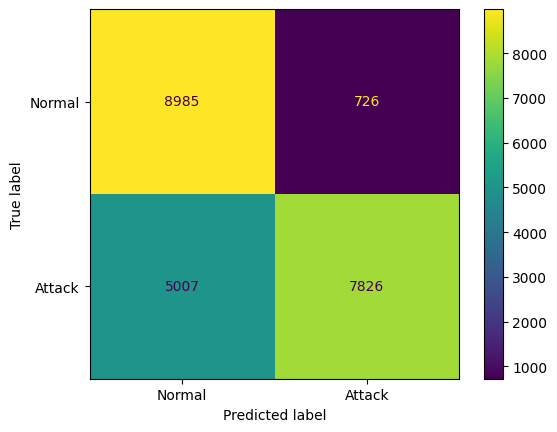

In [7]:
svm_result = evaluate_model(
    svm,
    X_train_scaled,
    y_train,
    X_test_scaled,
    y_test
)